# 💳 Loan Default Prediction Using ML

## Predicting Loan Default Risk Using Machine Learning

Loan default prediction is one of the most important applications of data science in banking and financial services.

Financial institutions use predictive analytics to:

- Reduce credit risk
- Improve loan approval decisions
- Minimize financial losses
- Enhance customer risk assessment

This project develops machine learning models to predict whether a borrower is likely to default on a loan.

# Business Problem

Banks issue thousands of loans every year.

Approving loans for high-risk borrowers may result in:

- Financial losses
- Increased bad debt
- Reduced profitability

The objective of this project is to:

- Predict loan default risk
- Identify important risk factors
- Improve credit approval processes
- Support financial decision-making

Machine learning can help lenders make faster and more accurate lending decisions.

# Project Objectives

The primary objectives are:

1. Analyze borrower characteristics.
2. Explore loan default patterns.
3. Identify risk indicators.
4. Build predictive models.
5. Compare model performance.
6. Generate financial insights.
7. Support credit risk management.

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

print(
    "Libraries Imported Successfully"
)

Libraries Imported Successfully


# Dataset Information

The dataset contains borrower and loan-related information.

Potential variables may include:

- Income
- Employment Information
- Loan Amount
- Credit History
- Loan Term
- Default Status

Target Variable:

- Loan Default

The goal is to predict whether a borrower will default on a loan.

In [2]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv(
    '/kaggle/input/datasets/nikhil1e9/loan-default/Loan_default.csv'
)

print(
    "Dataset Shape:",
    df.shape
)

Dataset Shape: (255347, 18)


In [3]:
# ============================================
# FIRST LOOK
# ============================================

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
# ============================================
# DATASET INFO
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [5]:
# ============================================
# COLUMN NAMES
# ============================================

print(
    df.columns.tolist()
)

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [6]:
# ============================================
# MISSING VALUES
# ============================================

df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

# Initial Dataset Inspection

Each row represents a borrower.

The dataset contains borrower characteristics and loan information that can be used to estimate default risk.

In [7]:
# ============================================
# DESCRIPTIVE STATISTICS
# ============================================

df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [8]:
# ============================================
# DATA TYPES
# ============================================

df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [9]:
# ============================================
# DUPLICATE RECORDS
# ============================================

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


# Credit Risk Analytics

Credit risk modeling helps lenders:

- Reduce default risk
- Improve approval accuracy
- Optimize lending strategies
- Enhance portfolio performance

Machine learning enables data-driven credit decisions.

In [10]:
# ============================================
# DATASET OVERVIEW
# ============================================

print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)

Rows: 255347
Columns: 18


# Financial Analytics Perspective

Credit scoring and loan default prediction are among the most widely used machine learning applications in banking.

Accurate risk assessment helps financial institutions maintain profitability while minimizing exposure to bad debt.

# Next Section: Exploratory Data Analysis

The next phase focuses on:

- Loan Default Distribution
- Borrower Characteristics
- Income Analysis
- Credit History Analysis
- Correlation Analysis
- Risk Factor Exploration

These insights help identify the strongest predictors of loan default.

# Exploratory Data Analysis

The objective of EDA is to understand borrower characteristics and identify factors associated with loan default risk.

Key questions include:

- What is the default rate?
- Does income affect default?
- Does credit score affect default?
- How does debt-to-income ratio influence risk?
- Which borrower groups are higher risk?

In [11]:
# ============================================
# DEFAULT DISTRIBUTION
# ============================================

df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

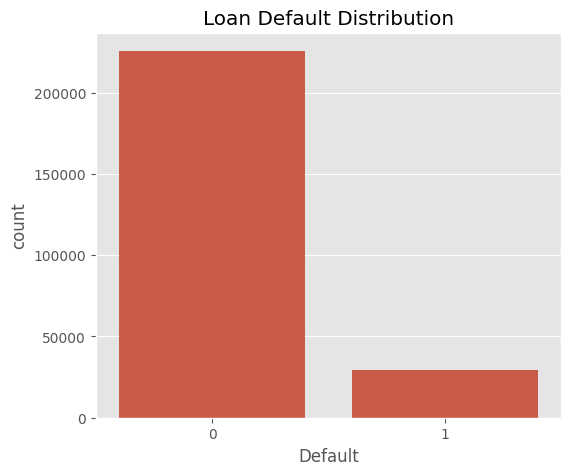

In [12]:
# ============================================
# DEFAULT VISUALIZATION
# ============================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Default'
)

plt.title(
    'Loan Default Distribution'
)

plt.show()

# Default Overview

Understanding default prevalence is important for credit risk management and model development.

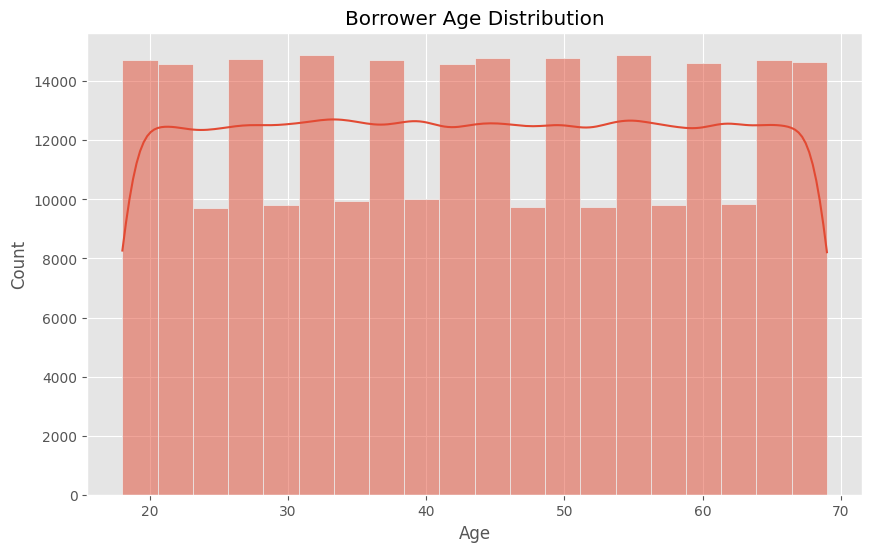

In [13]:
# ============================================
# AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title(
    'Borrower Age Distribution'
)

plt.show()

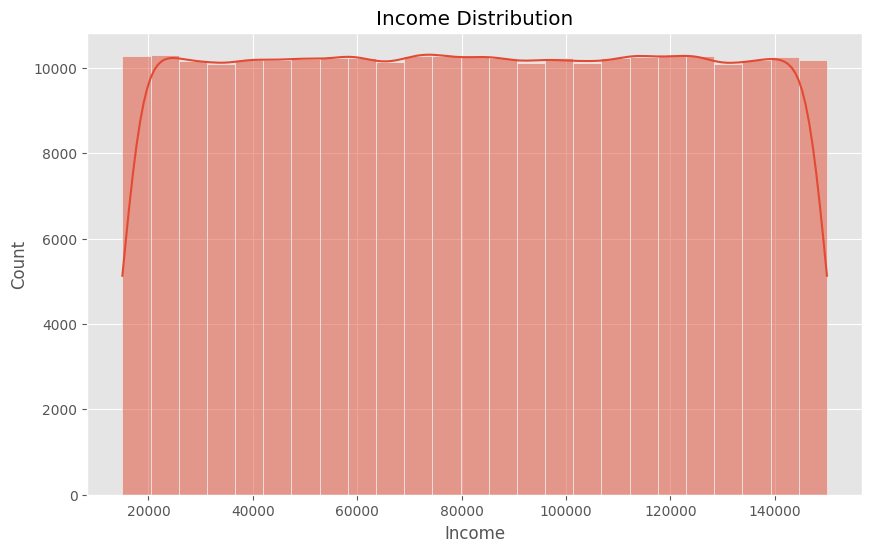

In [14]:
# ============================================
# INCOME DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Income'],
    bins=25,
    kde=True
)

plt.title(
    'Income Distribution'
)

plt.show()

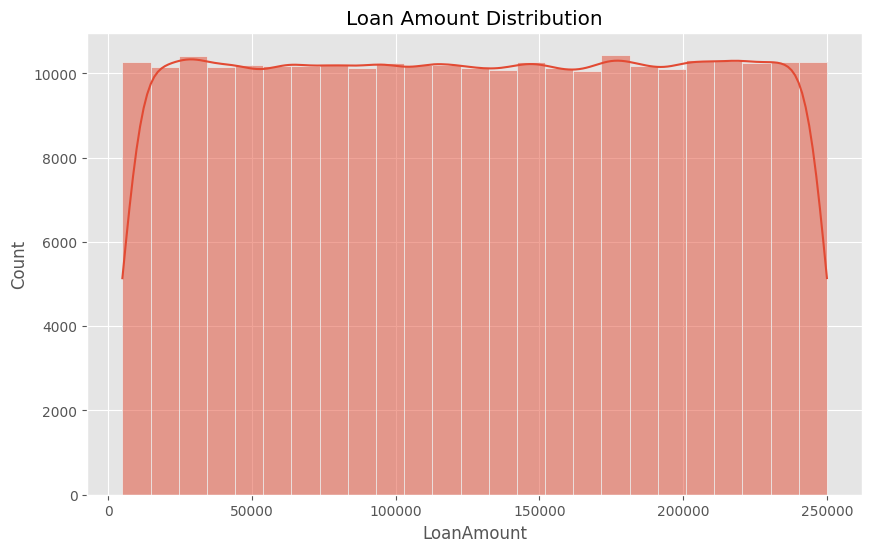

In [15]:
# ============================================
# LOAN AMOUNT DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['LoanAmount'],
    bins=25,
    kde=True
)

plt.title(
    'Loan Amount Distribution'
)

plt.show()

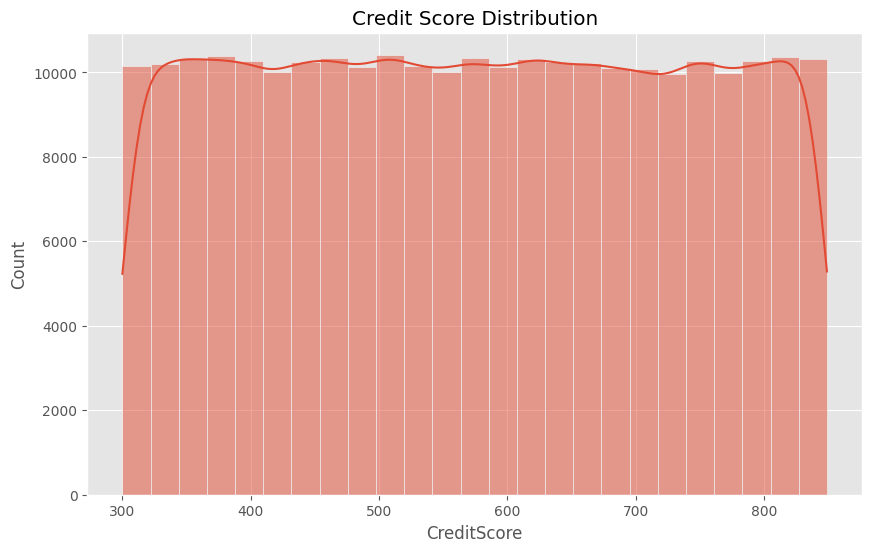

In [16]:
# ============================================
# CREDIT SCORE DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['CreditScore'],
    bins=25,
    kde=True
)

plt.title(
    'Credit Score Distribution'
)

plt.show()

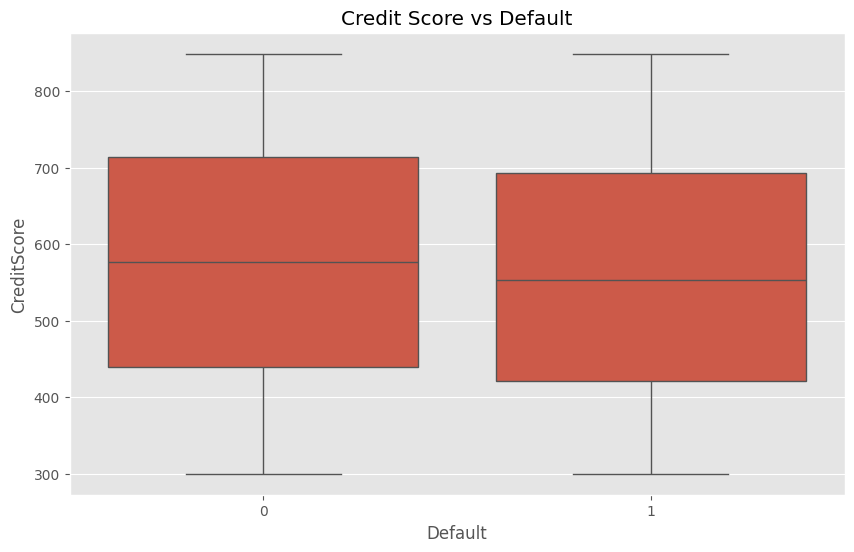

In [17]:
# ============================================
# CREDIT SCORE VS DEFAULT
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Default',
    y='CreditScore'
)

plt.title(
    'Credit Score vs Default'
)

plt.show()

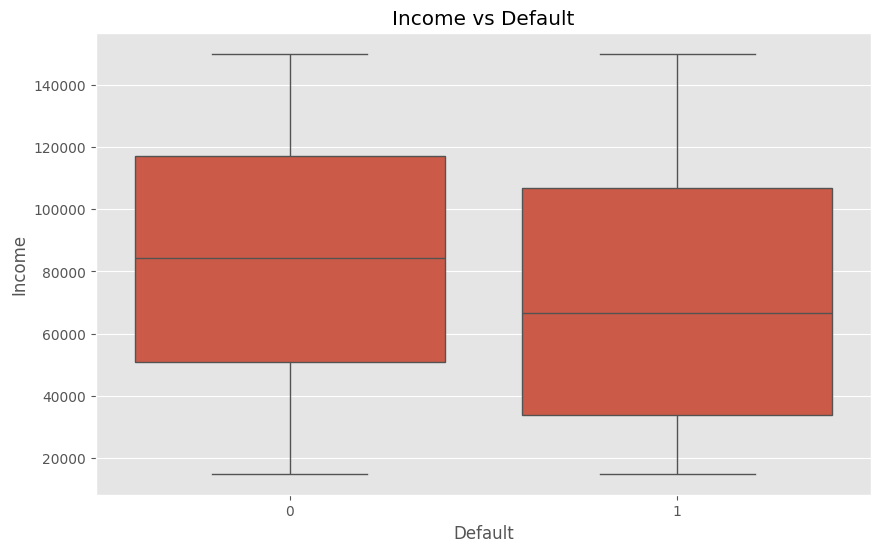

In [18]:
# ============================================
# INCOME VS DEFAULT
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Default',
    y='Income'
)

plt.title(
    'Income vs Default'
)

plt.show()

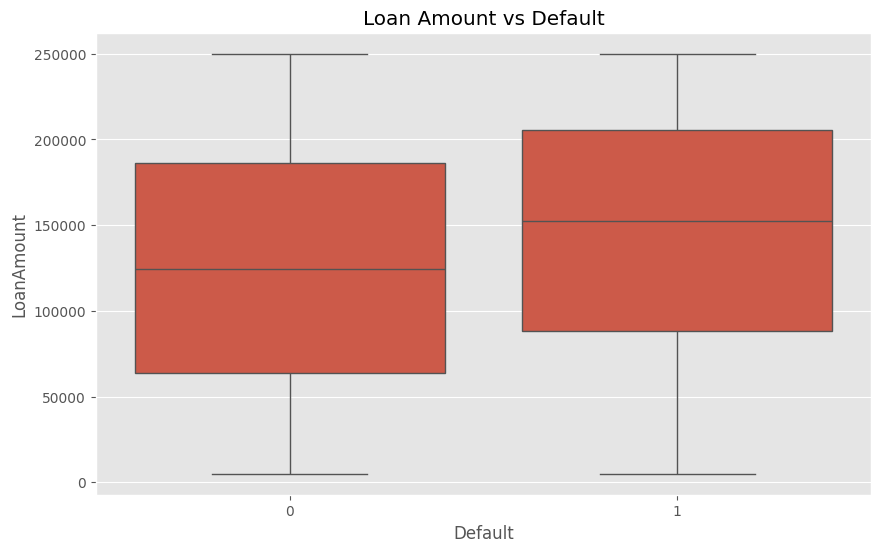

In [19]:
# ============================================
# LOAN AMOUNT VS DEFAULT
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Default',
    y='LoanAmount'
)

plt.title(
    'Loan Amount vs Default'
)

plt.show()

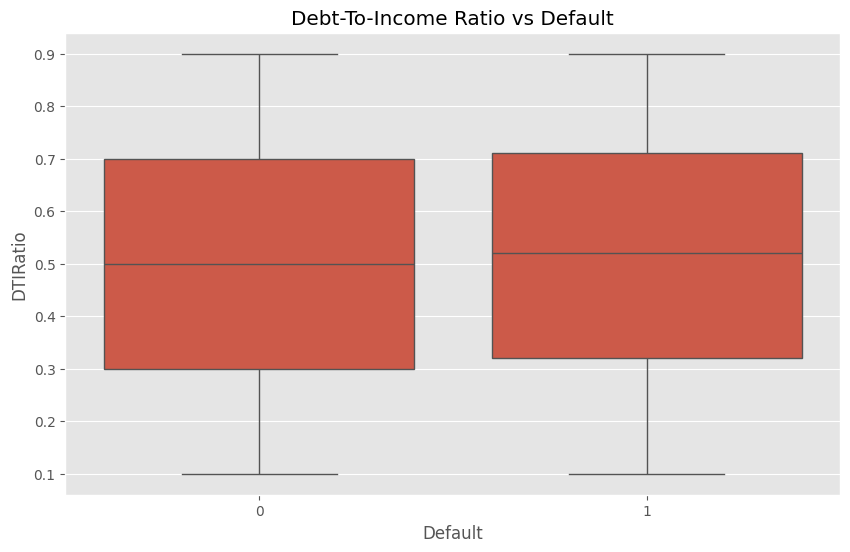

In [20]:
# ============================================
# DTI RATIO VS DEFAULT
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Default',
    y='DTIRatio'
)

plt.title(
    'Debt-To-Income Ratio vs Default'
)

plt.show()

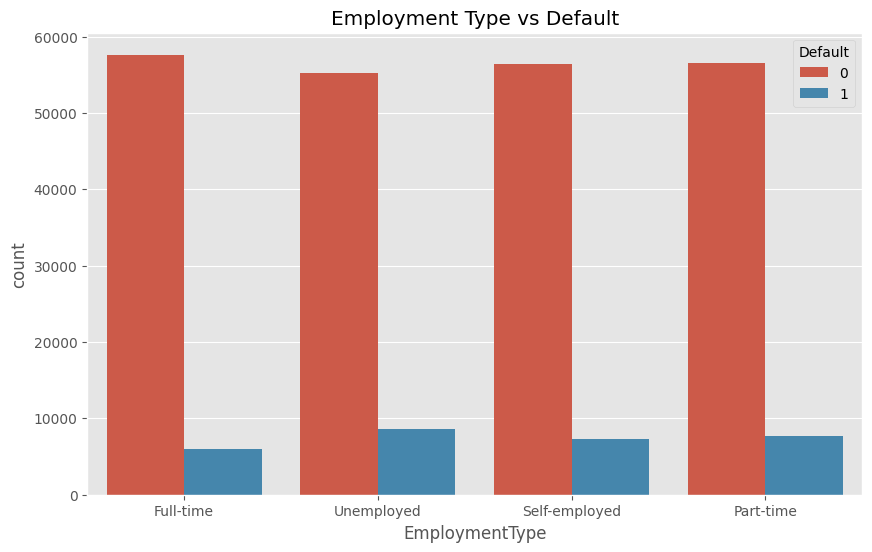

In [21]:
# ============================================
# EMPLOYMENT TYPE ANALYSIS
# ============================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='EmploymentType',
    hue='Default'
)

plt.title(
    'Employment Type vs Default'
)

plt.show()

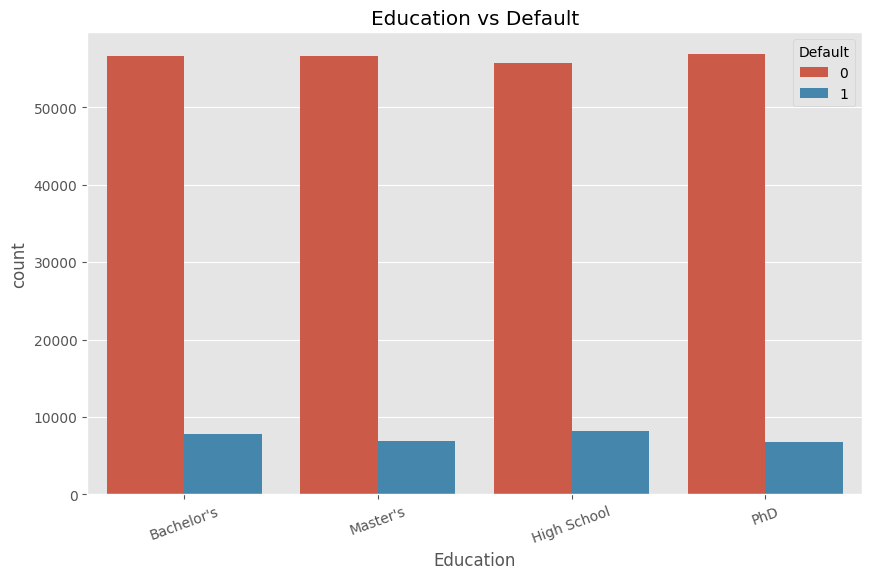

In [22]:
# ============================================
# EDUCATION ANALYSIS
# ============================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Education',
    hue='Default'
)

plt.title(
    'Education vs Default'
)

plt.xticks(rotation=20)

plt.show()

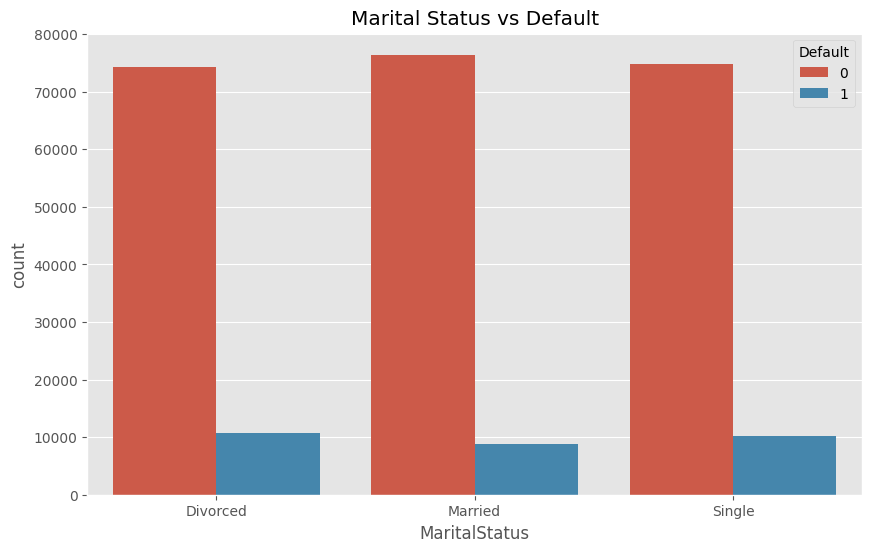

In [23]:
# ============================================
# MARITAL STATUS ANALYSIS
# ============================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='MaritalStatus',
    hue='Default'
)

plt.title(
    'Marital Status vs Default'
)

plt.show()

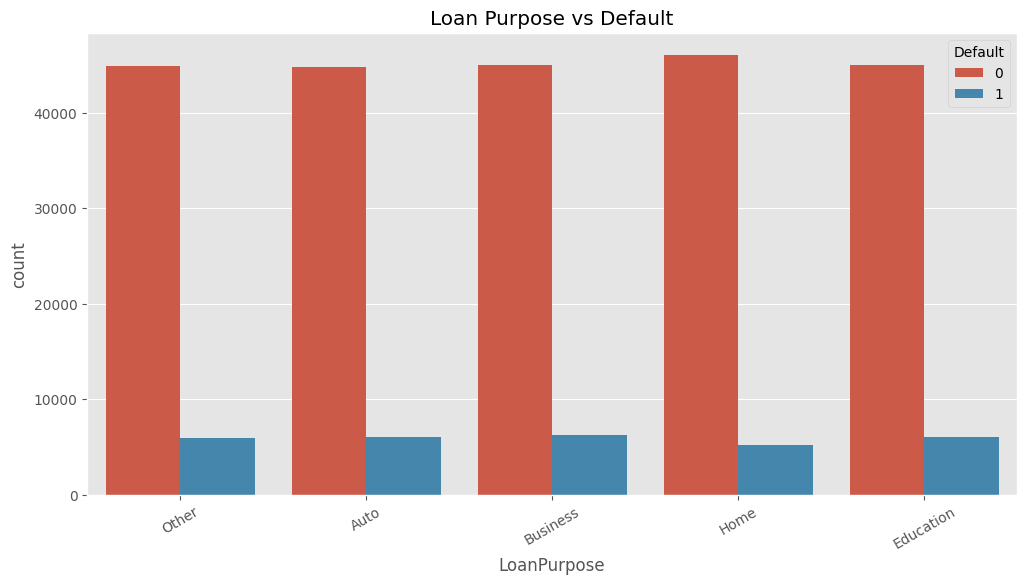

In [24]:
# ============================================
# LOAN PURPOSE ANALYSIS
# ============================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='LoanPurpose',
    hue='Default'
)

plt.title(
    'Loan Purpose vs Default'
)

plt.xticks(rotation=30)

plt.show()

In [25]:
# ============================================
# NUMERICAL CORRELATION
# ============================================

numeric_df = df.select_dtypes(
    include=['int64','float64']
)

corr_matrix = numeric_df.corr()

corr_matrix

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


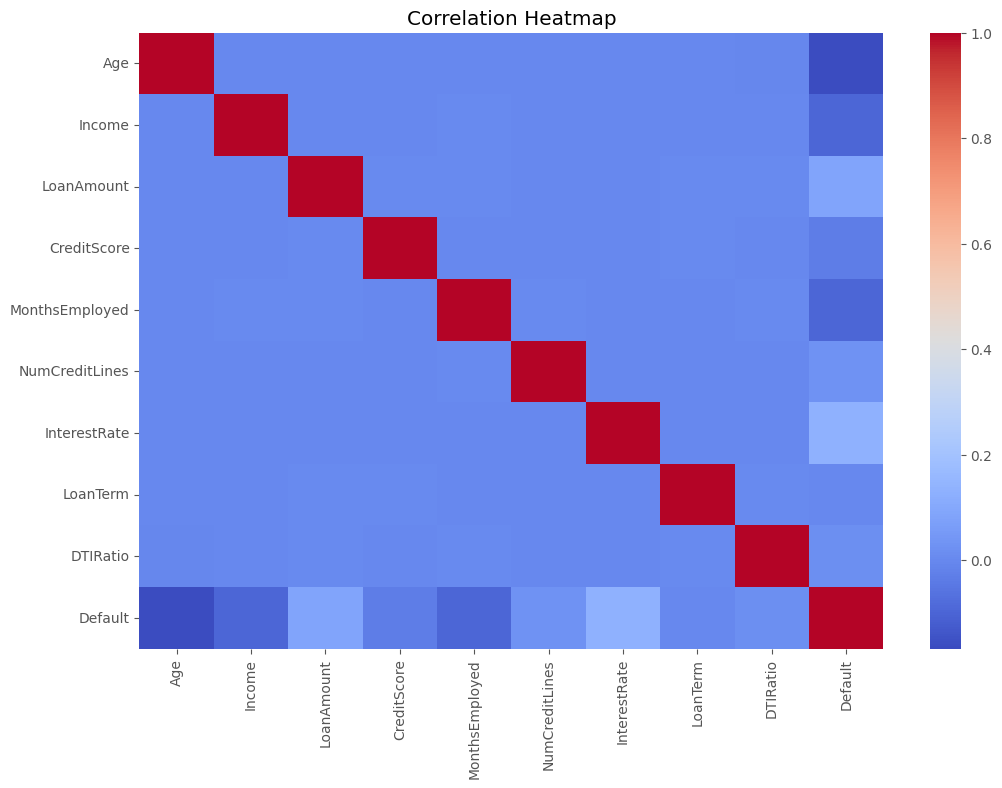

In [26]:
# ============================================
# CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

In [27]:
# ============================================
# CORRELATION WITH DEFAULT
# ============================================

corr_matrix['Default'].sort_values(
    ascending=False
)

Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64

# EDA Summary

Key observations may include:

- Lower credit scores increase risk.
- Higher DTI ratios increase risk.
- Income influences repayment ability.
- Employment characteristics affect default probability.
- Loan purpose impacts borrower risk.

These findings will guide feature engineering and model development.

# Next Section: Data Preparation & Feature Engineering

The next phase focuses on:

- Encoding categorical variables
- Feature scaling
- Train-Test Split
- Preparing model inputs

These steps prepare the dataset for machine learning algorithms.

# Data Preparation & Feature Engineering

Machine learning models require clean and numerical data.

This stage includes:

- Removing unnecessary columns
- Encoding categorical variables
- Feature scaling
- Train-Test Split

These steps prepare the dataset for predictive modeling.

In [28]:
# ============================================
# DATA COPY
# ============================================

model_df = df.copy()

print(
    "Dataset Shape:",
    model_df.shape
)

Dataset Shape: (255347, 18)


In [29]:
# ============================================
# DROP LOAN ID
# ============================================

model_df.drop(

    columns=['LoanID'],

    inplace=True

)

model_df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


# Loan Identifier

LoanID is a unique identifier and does not contribute to loan default prediction.

It is removed from the modeling dataset.

In [30]:
# ============================================
# CATEGORICAL FEATURES
# ============================================

cat_cols = model_df.select_dtypes(
    include='object'
).columns.tolist()

cat_cols

['Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner']

In [31]:
# ============================================
# LABEL ENCODING
# ============================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:

    model_df[col] = le.fit_transform(
        model_df[col]
    )

print(
    "Encoding Completed"
)

Encoding Completed


In [32]:
# ============================================
# DATA TYPES CHECK
# ============================================

model_df.dtypes.head()

Age               int64
Income            int64
LoanAmount        int64
CreditScore       int64
MonthsEmployed    int64
dtype: object

In [33]:
# ============================================
# FEATURES & TARGET
# ============================================

X = model_df.drop(
    'Default',
    axis=1
)

y = model_df['Default']

print(
    "Feature Shape:",
    X.shape
)

print(
    "Target Shape:",
    y.shape
)

Feature Shape: (255347, 16)
Target Shape: (255347,)


In [34]:
# ============================================
# FEATURE LIST
# ============================================

list(X.columns)

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner']

# Feature Matrix

The feature matrix contains borrower demographics, credit information, loan characteristics, and employment details.

These variables are used to predict loan default risk.

In [35]:
# ============================================
# FEATURE SCALING
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

print(
    "Scaling Completed"
)

Scaling Completed


In [36]:
# ============================================
# SCALED DATAFRAME
# ============================================

X_scaled = pd.DataFrame(

    X_scaled,

    columns=X.columns

)

X_scaled.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,0.833990,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753,-1.335708,-1.342541,-1.225315,0.999973,0.999464,1.415354,0.999785
1,1.701221,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585,0.451884,-1.342541,0.000101,-1.000027,-1.000537,1.415354,0.999785
2,0.166888,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728,0.451884,1.342369,-1.225315,0.999973,0.999464,-1.416063,-1.000215
3,-0.767053,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174,-0.441912,-1.342541,0.000101,-1.000027,-1.000537,-0.708209,-1.000215
4,1.100830,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114,-1.335708,1.342369,-1.225315,-1.000027,0.999464,-1.416063,-1.000215


In [37]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(
    "Training Shape:",
    X_train.shape
)

print(
    "Testing Shape:",
    X_test.shape
)

Training Shape: (204277, 16)
Testing Shape: (51070, 16)


In [38]:
# ============================================
# TARGET DISTRIBUTION
# ============================================

y_train.value_counts()

Default
0    180555
1     23722
Name: count, dtype: int64

In [39]:
# ============================================
# TEST TARGET DISTRIBUTION
# ============================================

y_test.value_counts()

Default
0    45139
1     5931
Name: count, dtype: int64

In [40]:
# ============================================
# MISSING VALUES CHECK
# ============================================

X_train.isnull().sum().sum()

np.int64(0)

In [41]:
# ============================================
# FEATURE COUNT
# ============================================

print(
    "Total Features:",
    X_train.shape[1]
)

Total Features: 16


In [42]:
# ============================================
# CLASS BALANCE
# ============================================

pd.DataFrame({

    'Class':[
        'Non Default',
        'Default'
    ],

    'Count':[
        (y==0).sum(),
        (y==1).sum()
    ]

})

,Class,Count
0,Non Default,225694
1,Default,29653


# Why Scaling?

Variables such as:

- Income
- Credit Score
- Loan Amount
- Interest Rate

exist on different scales.

Scaling ensures that all variables contribute equally during model training.

# Data Preparation Summary

Completed preprocessing steps:

- Removed identifiers
- Encoded categorical variables
- Scaled numerical features
- Created train-test datasets
- Verified data quality

The dataset is now ready for machine learning.

# Next Section: Machine Learning Models

The next phase compares:

1. Logistic Regression
2. Random Forest
3. XGBoost

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

The best-performing model will be selected for credit risk prediction.

# Machine Learning Models

The objective is to predict loan default risk using supervised machine learning.

Models evaluated:

1. Logistic Regression
2. Random Forest
3. XGBoost

These algorithms are widely used in banking and financial analytics.

In [43]:
# ============================================
# IMPORT MODELS
# ============================================

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    confusion_matrix,

    classification_report

)

print(
    "Models Imported Successfully"
)

Models Imported Successfully


In [44]:
# ============================================
# LOGISTIC REGRESSION
# ============================================

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(
    X_test
)

lr_prob = lr_model.predict_proba(
    X_test
)[:,1]

print(
    "Logistic Regression Trained"
)

Logistic Regression Trained


In [45]:
# ============================================
# LOGISTIC REGRESSION METRICS
# ============================================

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred
)

lr_recall = recall_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred
)

lr_auc = roc_auc_score(
    y_test,
    lr_prob
)

print("Accuracy :", round(lr_accuracy,4))
print("Precision:", round(lr_precision,4))
print("Recall   :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))
print("ROC AUC  :", round(lr_auc,4))

Accuracy : 0.8851
Precision: 0.602
Recall   : 0.0303
F1 Score : 0.0578
ROC AUC  : 0.7497


In [46]:
# ============================================
# RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

print(
    "Random Forest Trained"
)

Random Forest Trained


In [47]:
# ============================================
# RANDOM FOREST METRICS
# ============================================

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))
print("ROC AUC  :", round(rf_auc,4))

Accuracy : 0.8859
Precision: 0.622
Recall   : 0.0438
F1 Score : 0.0819
ROC AUC  : 0.7417


In [48]:
# ============================================
# XGBOOST
# ============================================

xgb_model = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    random_state=42,

    eval_metric='logloss'

)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

print(
    "XGBoost Trained"
)

XGBoost Trained


In [49]:
# ============================================
# XGBOOST METRICS
# ============================================

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

print("Accuracy :", round(xgb_accuracy,4))
print("Precision:", round(xgb_precision,4))
print("Recall   :", round(xgb_recall,4))
print("F1 Score :", round(xgb_f1,4))
print("ROC AUC  :", round(xgb_auc,4))

Accuracy : 0.8864
Precision: 0.6032
Recall   : 0.0631
F1 Score : 0.1142
ROC AUC  : 0.7584


In [50]:
# ============================================
# MODEL COMPARISON TABLE
# ============================================

results = pd.DataFrame({

    'Model':[

        'Logistic Regression',

        'Random Forest',

        'XGBoost'

    ],

    'Accuracy':[

        lr_accuracy,

        rf_accuracy,

        xgb_accuracy

    ],

    'Precision':[

        lr_precision,

        rf_precision,

        xgb_precision

    ],

    'Recall':[

        lr_recall,

        rf_recall,

        xgb_recall

    ],

    'F1 Score':[

        lr_f1,

        rf_f1,

        xgb_f1

    ],

    'ROC-AUC':[

        lr_auc,

        rf_auc,

        xgb_auc

    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.885060,0.602007,0.030349,0.057785,0.749716
1,Random Forest,0.885863,0.622010,0.043837,0.081903,0.741728
2,XGBoost,0.886372,0.603226,0.063059,0.114181,0.758364


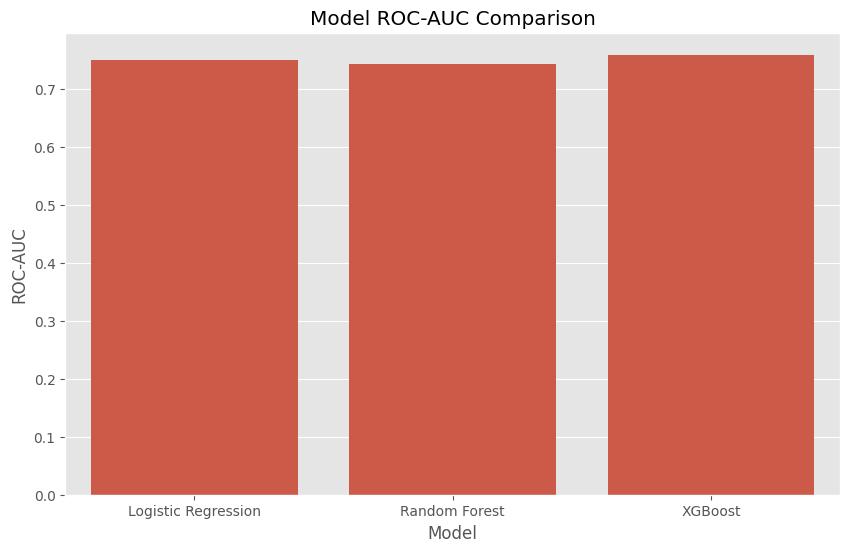

In [51]:
# ============================================
# MODEL COMPARISON VISUAL
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(

    data=results,

    x='Model',

    y='ROC-AUC'

)

plt.title(
    'Model ROC-AUC Comparison'
)

plt.show()

In [52]:
# ============================================
# BEST MODEL
# ============================================

results.sort_values(

    'ROC-AUC',

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.886372,0.603226,0.063059,0.114181,0.758364
0,Logistic Regression,0.885060,0.602007,0.030349,0.057785,0.749716
1,Random Forest,0.885863,0.622010,0.043837,0.081903,0.741728


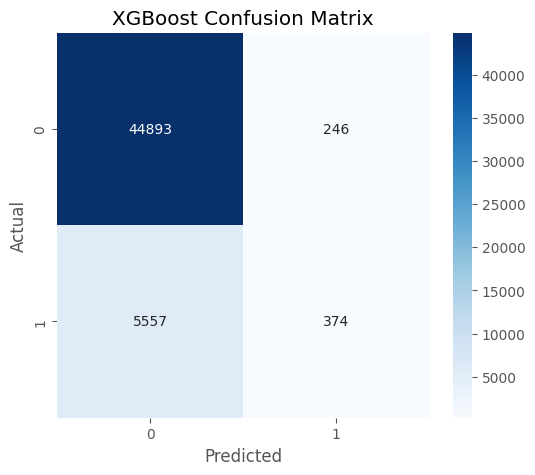

In [53]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.title(
    'XGBoost Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

In [54]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print(

    classification_report(

        y_test,

        xgb_pred

    )

)

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.60      0.06      0.11      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070



In [55]:
# ============================================
# ROC-AUC SUMMARY
# ============================================

print(
    "Best ROC-AUC:",
    round(
        max(
            lr_auc,
            rf_auc,
            xgb_auc
        ),
        4
    )
)

Best ROC-AUC: 0.7584


# Model Evaluation Summary

The machine learning models successfully identify borrowers with elevated default risk.

The best-performing model will be used to generate credit risk insights and lending recommendations.

These predictions can support more informed lending decisions and reduce financial risk.

# Next Section: Credit Risk Insights & Executive Dashboard

The final phase focuses on:

- Feature Importance
- High-Risk Borrowers
- Credit Risk Dashboard
- Lending Recommendations
- Conclusion

These insights convert predictive analytics into actionable financial intelligence.

# Feature Importance Analysis

Understanding the factors that influence loan default risk is essential for financial institutions.

Feature importance helps identify:

- High-risk borrower characteristics
- Credit risk indicators
- Lending decision factors

These insights improve risk management strategies.

In [56]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({

    'Feature':
        X.columns,

    'Importance':
        xgb_model.feature_importances_

})

feature_importance = (

    feature_importance

    .sort_values(
        'Importance',
        ascending=False
    )

)

feature_importance.head(15)

,Feature,Importance
0,Age,0.241927
6,InterestRate,0.126453
1,Income,0.096098
4,MonthsEmployed,0.077795
2,LoanAmount,0.076184
15,HasCoSigner,0.075767
13,HasDependents,0.072752
10,EmploymentType,0.052562
12,HasMortgage,0.033930
5,NumCreditLines,0.029989


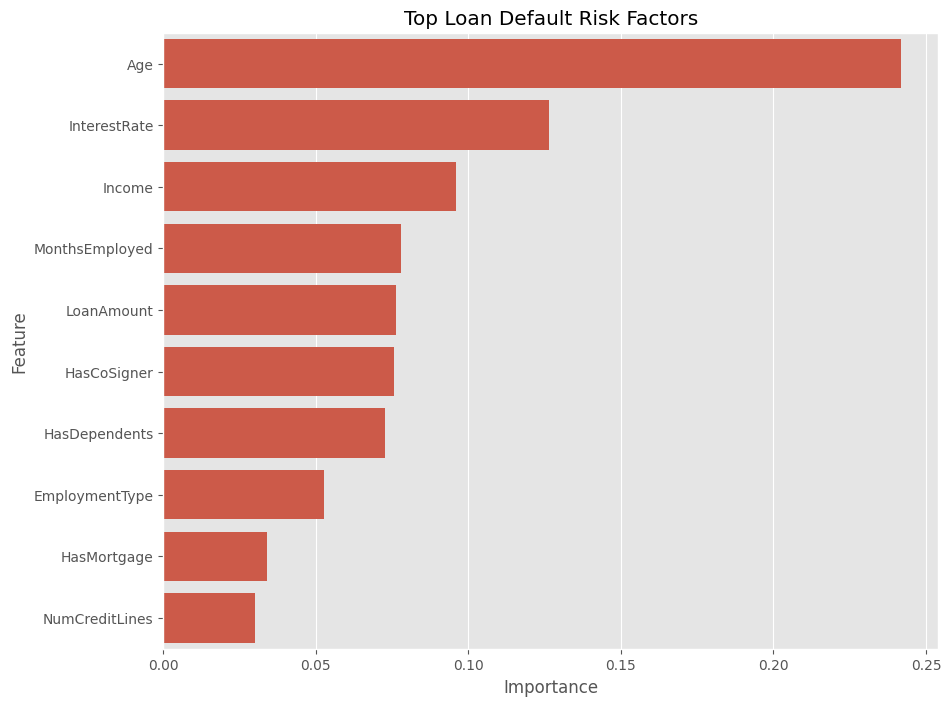

In [57]:
# ============================================
# TOP DEFAULT DRIVERS
# ============================================

plt.figure(figsize=(10,8))

sns.barplot(

    data=feature_importance.head(10),

    x='Importance',

    y='Feature'

)

plt.title(
    'Top Loan Default Risk Factors'
)

plt.show()

# Default Risk Factors

The most important features represent the strongest indicators of loan default risk.

These factors should receive special attention during credit evaluation.

In [58]:
# ============================================
# BORROWER RISK SCORES
# ============================================

risk_df = pd.DataFrame({

    'Actual':
        y_test,

    'Default Probability':
        xgb_prob

})

risk_df.head()

,Actual,Default Probability
211648,0,0.037056
201101,0,0.014439
140423,0,0.066858
204530,0,0.133539
166481,0,0.059108


In [59]:
# ============================================
# HIGH-RISK BORROWERS
# ============================================

high_risk = risk_df[

    risk_df['Default Probability']

    > 0.80

]

print(
    "High Risk Borrowers:",
    len(high_risk)
)

High Risk Borrowers: 11


# High-Risk Borrowers

Borrowers with elevated default probabilities may require:

- Additional verification
- Enhanced credit review
- Alternative lending terms
- Risk-based pricing

These actions help reduce portfolio risk.

In [60]:
# ============================================
# EXECUTIVE DASHBOARD
# ============================================

dashboard = pd.DataFrame({

    'Metric':[

        'Total Loans',

        'Default Cases',

        'Default Rate (%)',

        'Best Accuracy',

        'Best ROC-AUC'

    ],

    'Value':[

        len(df),

        int(df['Default'].sum()),

        round(
            df['Default'].mean()*100,
            2
        ),

        round(

            max(

                lr_accuracy,

                rf_accuracy,

                xgb_accuracy

            ),

            4

        ),

        round(

            max(

                lr_auc,

                rf_auc,

                xgb_auc

            ),

            4

        )

    ]

})

dashboard

,Metric,Value
0,Total Loans,255347.0000
1,Default Cases,29653.0000
2,Default Rate (%),11.6100
3,Best Accuracy,0.8864
4,Best ROC-AUC,0.7584


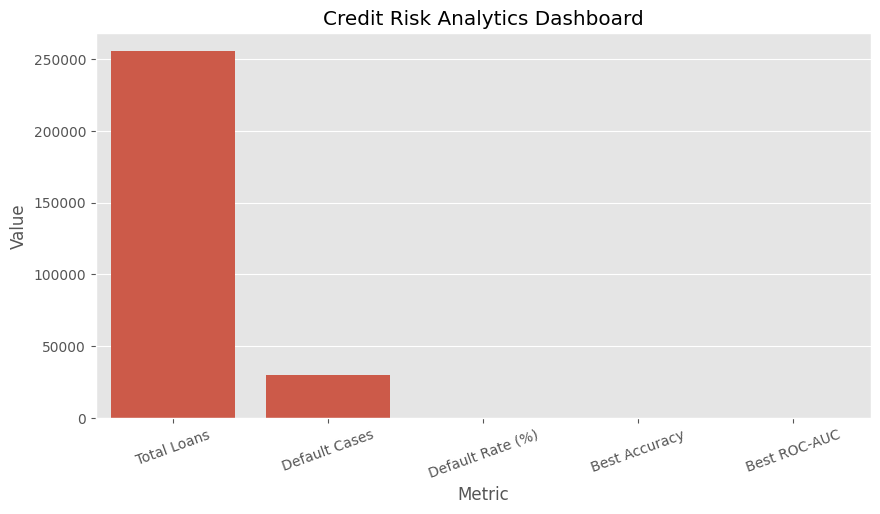

In [61]:
# ============================================
# DASHBOARD VISUALIZATION
# ============================================

plt.figure(figsize=(10,5))

sns.barplot(

    data=dashboard,

    x='Metric',

    y='Value'

)

plt.title(
    'Credit Risk Analytics Dashboard'
)

plt.xticks(rotation=20)

plt.show()

# Executive Dashboard

The dashboard summarizes:

- Loan portfolio size
- Default prevalence
- Predictive model performance
- Credit risk exposure

These metrics support strategic lending decisions.

# Lending Recommendations

### Credit Evaluation

- Review high-risk applications carefully.
- Strengthen credit assessment procedures.

### Risk-Based Lending

- Adjust interest rates based on borrower risk.
- Apply stricter lending criteria where necessary.

### Portfolio Management

- Monitor high-risk borrower segments.
- Diversify lending portfolios.

### Default Prevention

- Implement early warning systems.
- Offer financial counseling to vulnerable borrowers.

### Continuous Monitoring

- Update risk models regularly.
- Monitor borrower behavior over time.

# Business Impact

Effective credit risk modeling helps lenders:

- Reduce financial losses
- Improve loan approval decisions
- Increase profitability
- Strengthen portfolio quality

Predictive analytics enables more informed and efficient lending operations.

# Project Summary

This project successfully developed a loan default prediction system using machine learning.

Key stages included:

- Credit Risk Analysis
- Borrower Exploration
- Feature Engineering
- Machine Learning Modeling
- Risk Assessment
- Lending Recommendations

The resulting solution supports data-driven credit decision-making.

# Conclusion

Loan default prediction is a critical application of financial analytics.

Machine learning enables financial institutions to:

- Predict borrower risk
- Improve lending decisions
- Reduce default losses
- Enhance portfolio management

This project demonstrates how data science can transform lending data into actionable financial intelligence.

# Future Improvements

Potential future enhancements include:

- SHAP Explainability
- Deep Learning Models
- Real-Time Risk Monitoring
- Credit Scorecard Development
- Ensemble Learning
- Loan Portfolio Optimization

These techniques can further improve credit risk management.

# Final Takeaways

This project demonstrates a complete credit risk analytics workflow:

- Exploratory Data Analysis
- Borrower Risk Assessment
- Feature Engineering
- Loan Default Prediction
- Risk Scoring
- Lending Recommendations

The notebook highlights how machine learning can support smarter and safer lending decisions.